In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns #visualisation
import matplotlib.pyplot as plt #visualisation
%matplotlib inline
sns.set(color_codes=True)
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [ ]:
my_file = pd.read_csv('/content/messy_car_dataset.csv')

In [ ]:
print(my_file)

          Make   Model  Year Engine Fuel Type  Engine HP  Engine Cylinders  \
0      Hyundai  ModelD  2022         Electric      206.0                 8   
1         Ford  ModelE  2011           Diesel      393.0                 4   
2          Kia  ModelD  2021         Electric      289.0                 4   
3       Nissan  ModelB  2013           Petrol      113.0                 4   
4       Toyota  ModelD  2011           Diesel      153.0                 4   
..         ...     ...   ...              ...        ...               ...   
205  Chevrolet  ModelD  2018           Diesel      395.0                 3   
206  Chevrolet  ModelA  2021         Electric      238.0                 6   
207     Nissan  ModelD  2011              NaN        NaN                 6   
208        BMW  ModelC  2010           Petrol      317.0                 6   
209        BMW  ModelE  2020           Petrol      135.0                 3   

    Transmission Type Driven_Wheels  No of doors Market Categor

In [ ]:
# Checking datatypes
my_file.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,int64
Transmission Type,object
Driven_Wheels,object
No of doors,int64
Market Category,object


In [ ]:
# Removing some irrelevant columns
my_file.drop (["Engine Fuel Type", "Market Category", "Vehicle Style", "Popularity", "No of doors", "Vehicle Size"], axis=1, inplace=True)


In [ ]:
print(my_file)

          Make   Model  Year  Engine HP  Engine Cylinders Transmission Type  \
0      Hyundai  ModelD  2022      206.0                 8         Automatic   
1         Ford  ModelE  2011      393.0                 4            Manual   
2          Kia  ModelD  2021      289.0                 4         Automatic   
3       Nissan  ModelB  2013      113.0                 4            Manual   
4       Toyota  ModelD  2011      153.0                 4            Manual   
..         ...     ...   ...        ...               ...               ...   
205  Chevrolet  ModelD  2018      395.0                 3            Manual   
206  Chevrolet  ModelA  2021      238.0                 6         Automatic   
207     Nissan  ModelD  2011        NaN                 6         Automatic   
208        BMW  ModelC  2010      317.0                 6         Automatic   
209        BMW  ModelE  2020      135.0                 3            Manual   

    Driven_Wheels  highway MPG  city mpg      MSRP 

In [ ]:
# Renaming some columns
renaming = my_file.rename(columns={"Engine Cylinders": "Cylinders", "Make": "Company",'highway MPG':'Highway_mileage','city mpg':'City_mileage'},inplace = True)

In [ ]:
# Now check the rename columns
print(my_file)

       Company   Model  Year  Engine HP  Cylinders Transmission Type  \
0      Hyundai  ModelD  2022      206.0          8         Automatic   
1         Ford  ModelE  2011      393.0          4            Manual   
2          Kia  ModelD  2021      289.0          4         Automatic   
3       Nissan  ModelB  2013      113.0          4            Manual   
4       Toyota  ModelD  2011      153.0          4            Manual   
..         ...     ...   ...        ...        ...               ...   
205  Chevrolet  ModelD  2018      395.0          3            Manual   
206  Chevrolet  ModelA  2021      238.0          6         Automatic   
207     Nissan  ModelD  2011        NaN          6         Automatic   
208        BMW  ModelC  2010      317.0          6         Automatic   
209        BMW  ModelE  2020      135.0          3            Manual   

    Driven_Wheels  Highway_mileage  City_mileage      MSRP  
0             FWD               30            25   31023.0  
1            

In [ ]:
# number of rows before removing duplicated rows
my_file.shape

(210, 10)

In [ ]:
# Let's check duplicates
my_file[my_file.duplicated()]


,Company,Model,Year,Engine HP,Cylinders,Transmission Type,Driven_Wheels,Highway_mileage,City_mileage,MSRP
201,Ford,ModelE,2011,393.0,4,Manual,4WD,31,31,40658.0
202,Kia,ModelD,2021,289.0,4,Automatic,RWD,22,19,45740.0
203,Nissan,ModelB,2013,113.0,4,Manual,FWD,34,21,29541.0
205,Chevrolet,ModelD,2018,395.0,3,Manual,FWD,32,23,17568.0
206,Chevrolet,ModelA,2021,238.0,6,Automatic,4WD,24,24,37662.0
208,BMW,ModelC,2010,317.0,6,Automatic,RWD,34,24,37403.0


In [ ]:
# Let's remove duplicates
my_file.drop_duplicates(inplace=True)

In [ ]:
# number of rows after removing duplicated rows

my_file.shape

(204, 10)

In [ ]:
# check for nan values in each columns
my_file.isnull().sum()

,0
Company,0
Model,0
Year,0
Engine HP,21
Cylinders,0
Transmission Type,0
Driven_Wheels,0
Highway_mileage,0
City_mileage,0
MSRP,20


In [ ]:
# Dropping missing values
my_file.dropna(inplace=True)

In [ ]:
# Now check the null values ( all 0)
my_file.isnull().sum()

,0
Company,0
Model,0
Year,0
Engine HP,0
Cylinders,0
Transmission Type,0
Driven_Wheels,0
Highway_mileage,0
City_mileage,0
MSRP,0


<Axes: xlabel='MSRP'>

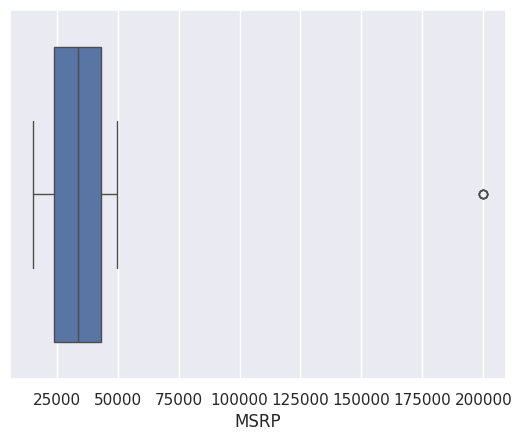

In [ ]:
## Plot a boxplot for 'Price' column in dataset.(MSRP hi price hai)

sns.boxplot(x=my_file['MSRP'])

<Axes: xlabel='Engine HP'>

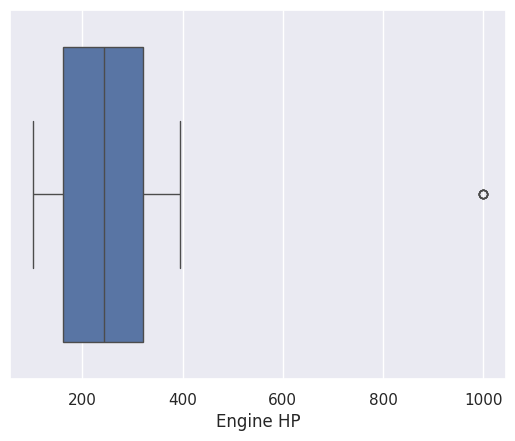

In [ ]:
## PLot a boxplot for 'HP' columns in dataset
sns.boxplot(x=my_file['Engine HP'])

In [ ]:
# print all the columns which are of int or float datatype in df.
my_file.select_dtypes(include=['int64','float64'])


,Year,Engine HP,Cylinders,Highway_mileage,City_mileage,MSRP
0,2022,206.0,8,30,25,31023.0
1,2011,393.0,4,31,31,40658.0
2,2021,289.0,4,22,19,45740.0
3,2013,113.0,4,34,21,29541.0
4,2011,153.0,4,21,24,47606.0
...,...,...,...,...,...,...
197,2015,233.0,6,31,26,31087.0
198,2021,376.0,8,39,16,20433.0
200,2022,206.0,8,30,25,200000.0
204,2011,1000.0,4,21,24,47606.0


In [ ]:
# save column names of the above output in variable list
l1 =  my_file.select_dtypes(include=['int64','float64'])


In [ ]:
## define Q1 and Q2
Q1 = np.percentile(my_file['MSRP'], 25)
Q2 = np.percentile(my_file['MSRP'], 75)

# # define IQR (interquantile range)
IQR =  Q2 - Q1

# df2 =
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q2 + 1.5 * IQR

# # define df2 after removing outliers
df2 = my_file[(my_file['MSRP'] >= lower_bound) & (my_file['MSRP'] <= upper_bound)]
print(df2)

     Company   Model  Year  Engine HP  Cylinders Transmission Type  \
0    Hyundai  ModelD  2022      206.0          8         Automatic   
1       Ford  ModelE  2011      393.0          4            Manual   
2        Kia  ModelD  2021      289.0          4         Automatic   
3     Nissan  ModelB  2013      113.0          4            Manual   
4     Toyota  ModelD  2011      153.0          4            Manual   
..       ...     ...   ...        ...        ...               ...   
195   Nissan  ModelD  2020      115.0          3         Automatic   
197   Nissan  ModelD  2015      233.0          6            Manual   
198    Honda  ModelC  2021      376.0          8            Manual   
204   Toyota  ModelD  2011     1000.0          4            Manual   
209      BMW  ModelE  2020      135.0          3            Manual   

    Driven_Wheels  Highway_mileage  City_mileage     MSRP  
0             FWD               30            25  31023.0  
1             4WD               31     

In [ ]:
# find the shape of df & df2
my_file.shape


(183, 10)

In [ ]:
df2.shape

(179, 10)

In [ ]:
# find unique values and there counts in each column in df using value counts function.
for i in my_file.columns:
    print(i)
    print(my_file[i].value_counts())   # inside loop



Company
Company
Honda        22
Tesla        21
Chevrolet    20
Toyota       20
Nissan       20
Hyundai      18
BMW          18
Kia          18
Ford         14
Audi         12
Name: count, dtype: int64
Model
Model
ModelD    47
ModelE    44
ModelC    37
ModelB    31
ModelA    24
Name: count, dtype: int64
Year
Year
2018    19
2017    19
2010    17
2022    16
2015    16
2011    14
2021    14
2016    13
2013    12
2019    12
2014    11
2020    10
2012    10
Name: count, dtype: int64
Engine HP
Engine HP
1000.0    5
272.0     3
135.0     3
246.0     3
206.0     3
         ..
267.0     1
277.0     1
115.0     1
233.0     1
376.0     1
Name: count, Length: 133, dtype: int64
Cylinders
Cylinders
4    52
6    47
8    42
3    42
Name: count, dtype: int64
Transmission Type
Transmission Type
Manual       93
Automatic    90
Name: count, dtype: int64
Driven_Wheels
Driven_Wheels
RWD    55
AWD    46
FWD    44
4WD    38
Name: count, dtype: int64
Highway_mileage
Highway_mileage
21    17
31    13
28    12


<Axes: xlabel='Engine HP', ylabel='Density'>

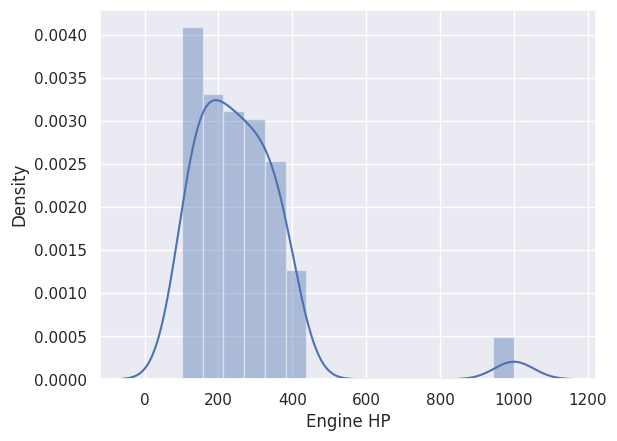

In [ ]:
#ploting distplot for variable HP

sns.distplot(my_file['Engine HP'])

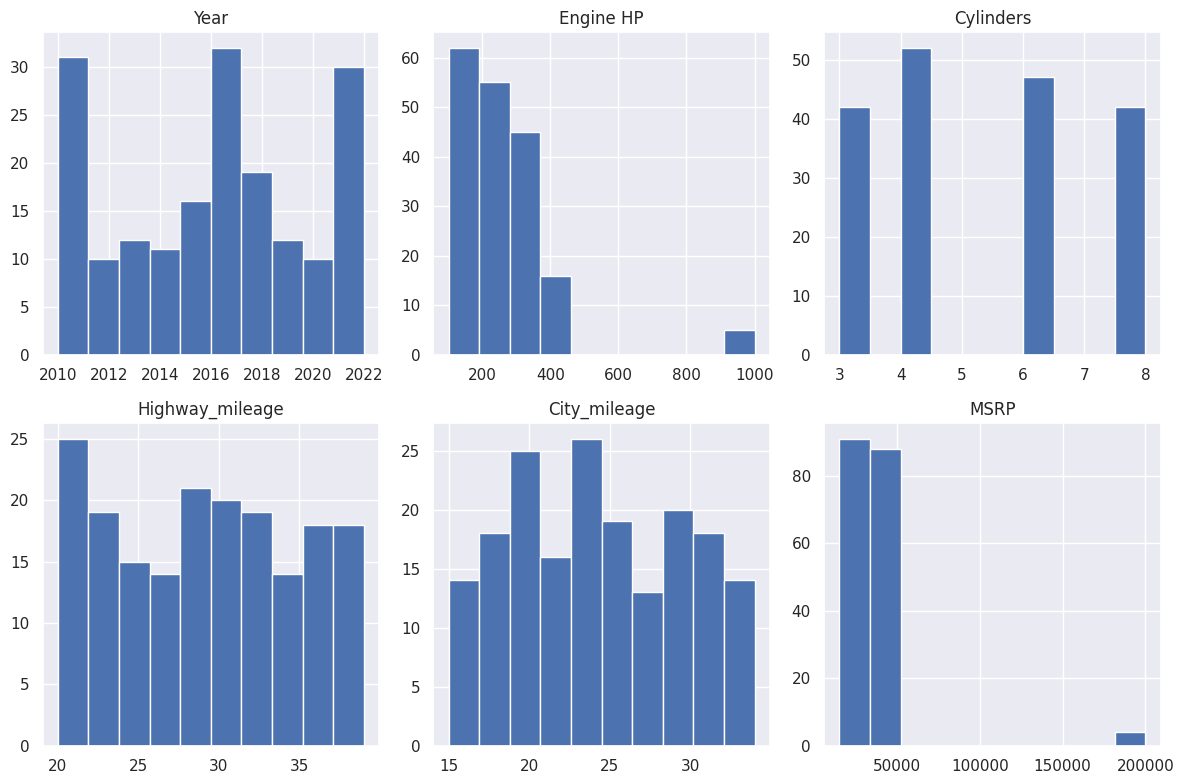

In [ ]:
# plot all the columns present in list l together using subplot of dimention (2,3).

plt.figure(figsize=(12,8))
for i,col in enumerate(l1,1):
    plt.subplot(2,3,i)
    plt.hist(my_file[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

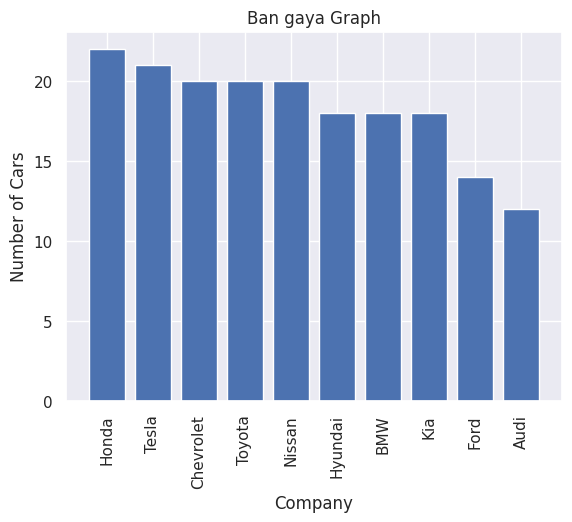

In [ ]:
# Plot a histogram depicting the make in X axis and number of cars in y axis. <br>
# (original) yahi vala hai bhai
counts = my_file['Company'].value_counts()
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.xlabel('Company')
plt.ylabel('Number of Cars')
plt.title('Ban gaya Graph')
plt.show()





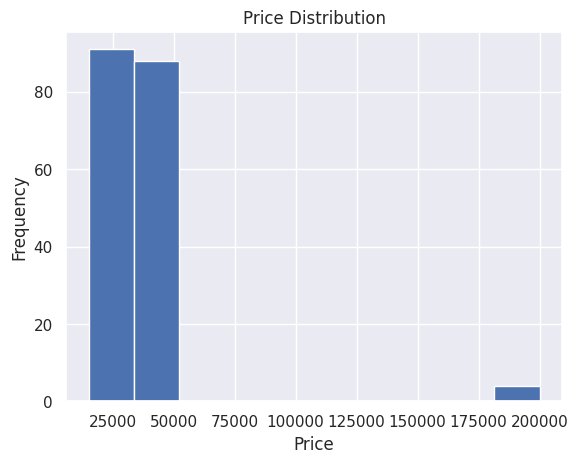

In [ ]:
# Plot a histogram depicting the make in X axis and number of cars in y axis. <br>

plt.hist(my_file['MSRP'])
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.show()

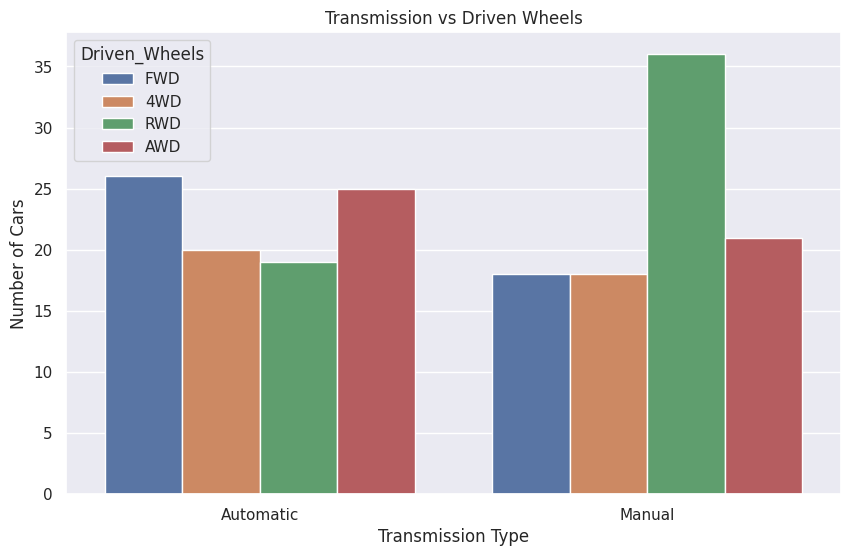

In [ ]:
 # Plot a countplot for a variable Transmission vertically with hue as Drive mode
 plt.figure(figsize=(10, 6))
sns.countplot(x='Transmission Type',
              data=my_file,
              hue='Driven_Wheels')

plt.xlabel('Transmission Type')
plt.ylabel('Number of Cars')   # just label, not data
plt.title('Transmission vs Driven Wheels')

plt.show()

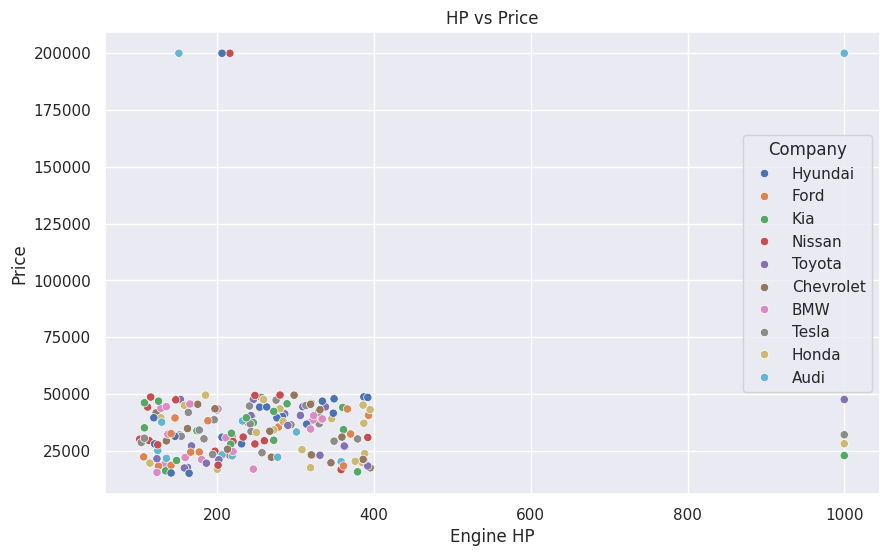

In [ ]:
# Using scatterplot find the correlation between 'HP' and 'Price' column of the data.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Engine HP',y='MSRP',data=my_file,hue='Company')
plt.xlabel('Engine HP')
plt.ylabel('Price')
plt.title('HP vs Price')
plt.show()

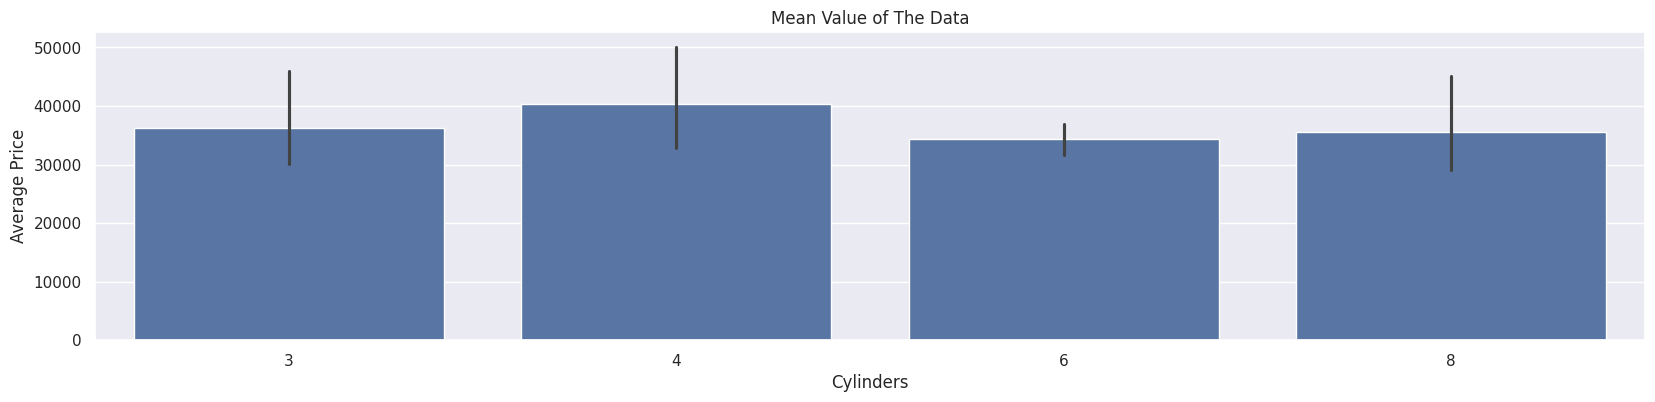

In [ ]:
# bar plot with default statistic=mean between Cylinder and Price
plt.figure(figsize=(20, 4))
sns.barplot(x= 'Cylinders', y='MSRP', data=my_file)
plt.xlabel('Cylinders')
plt.ylabel('Average Price')
plt.title('Mean Value of The Data')
plt.show()


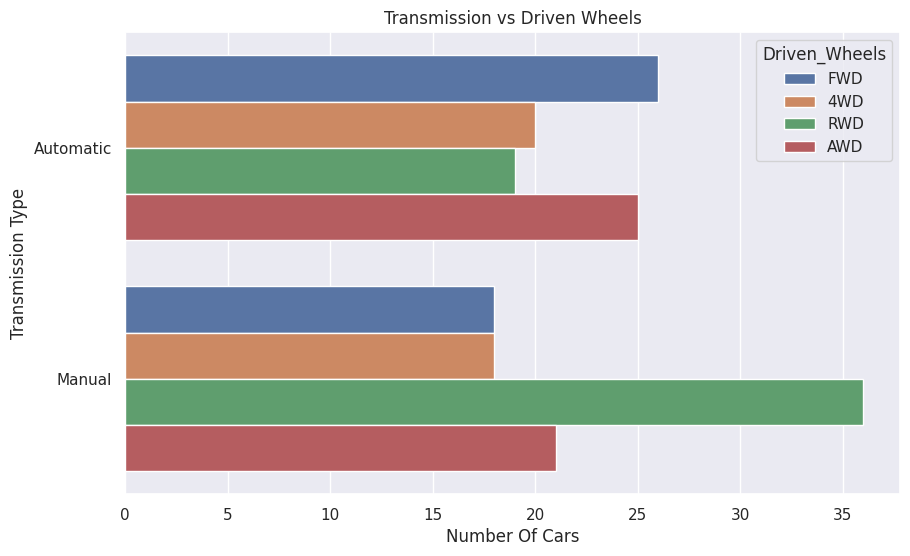

In [ ]:
# Plotting categorical variable Transmission across the y-axis
plt.figure(figsize=(10, 6))
sns.countplot(y='Transmission Type',
              data=my_file,
              hue='Driven_Wheels')

plt.xlabel('Number Of Cars')
plt.ylabel('Transmission Type')
plt.title('Transmission vs Driven Wheels')

plt.show()

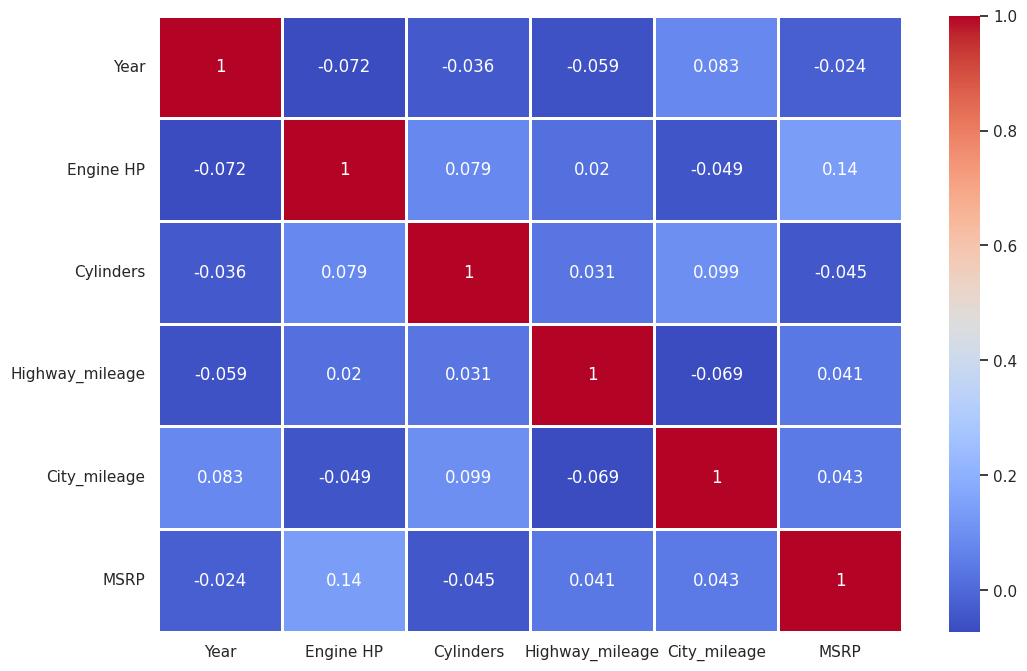

In [ ]:
# Using heatmaps plot the correlation between the features present in the dataset.
plt.figure(figsize=(12, 8))
sns.heatmap(l1.corr(), annot=True, cmap='coolwarm',linewidths=1)
plt.show()